In [2]:
# ================================
# 📦 IMPORT LIBRARIES
# ================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [3]:
# Load processed dataset from EDA
df = pd.read_csv("../data/processed/kidney_full.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,1


In [4]:
X = df.drop(columns=['classification'])
y = df['classification']

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (400, 24)
Target distribution:
 classification
1    250
0    150
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (320, 24)
Test shape: (80, 24)


In [6]:
# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: classification
1    200
0    120
Name: count, dtype: int64
After SMOTE: classification
1    200
0    200
Name: count, dtype: int64


SMOTE is applied only on training data to handle class imbalance and prevent data leakage.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

Feature scaling standardizes the data, ensuring all features contribute equally to model learning.

In [8]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train_res)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

Logistic Regression is used as a baseline model for comparison.

In [9]:
# Random Forest Model (Controlled to avoid overfitting)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          
    min_samples_split=10, 
    min_samples_leaf=5,  
    random_state=42
)

rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Random Forest is a tree-based model that captures complex patterns in the data.

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

Cross-validation scores: [0.975  1.     0.9625 0.9875 1.    ]
Mean CV score: 0.985


In [11]:
def evaluate_model(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [12]:
print("=== Logistic Regression ===")
evaluate_model(y_test, y_pred_lr)

=== Logistic Regression ===
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [13]:
print("=== Random Forest ===")
evaluate_model(y_test, y_pred_rf)

=== Random Forest ===
Accuracy : 0.9875
Precision: 0.9803921568627451
Recall   : 1.0
F1 Score : 0.9900990099009901

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



In [14]:
# Train Random Forest WITHOUT SMOTE (for comparison)
rf_no_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_no_smote.fit(X_train, y_train)

y_pred_no_smote = rf_no_smote.predict(X_test)

print("=== Random Forest WITHOUT SMOTE ===")
evaluate_model(y_test, y_pred_no_smote)

=== Random Forest WITHOUT SMOTE ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



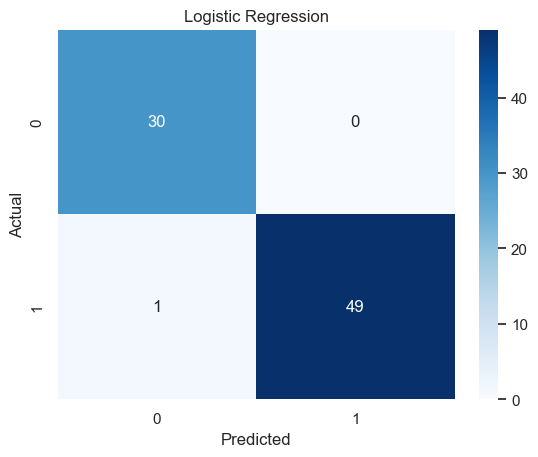

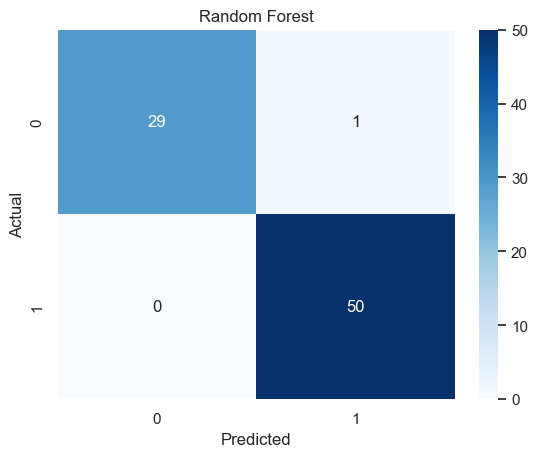

In [15]:
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, y_pred_lr, "Logistic Regression")
plot_confusion(y_test, y_pred_rf, "Random Forest")

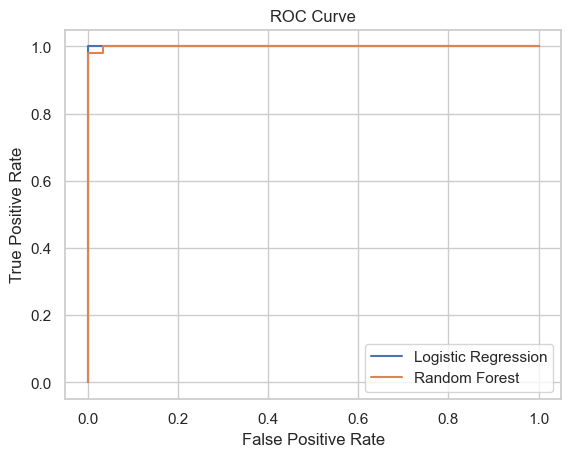

In [16]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Top Features:
 pcv     0.185301
sc      0.162286
hemo    0.162141
rc      0.142250
sg      0.094628
al      0.062019
dm      0.047668
htn     0.031331
bu      0.030196
sod     0.024304
dtype: float64


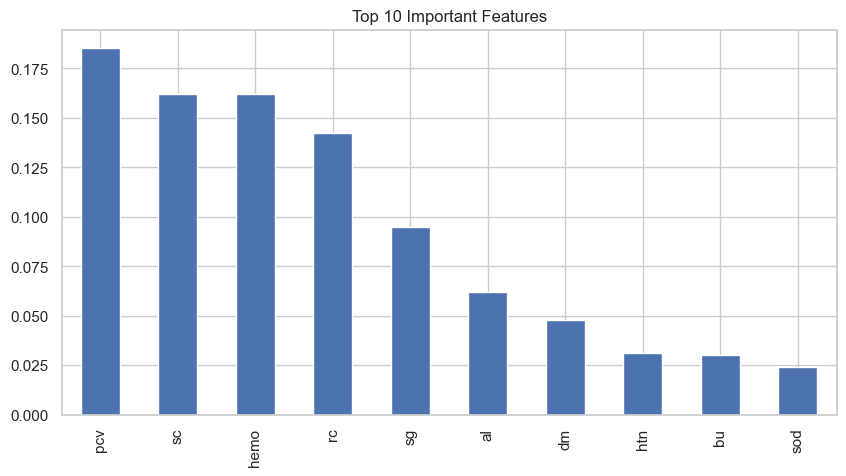

In [17]:
importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print("Top Features:\n", feat_imp.head(10))

plt.figure(figsize=(10,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

Feature importance shows which medical attributes most influence prediction.

In [18]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Recall,F1 Score
0,Logistic Regression,0.9875,0.98,0.989899
1,Random Forest,0.9875,1.00,0.990099


Random Forest performed better than Logistic Regression in terms of recall and F1-score.
Since this is a medical dataset, recall is prioritized to minimize false negatives (missing CKD cases).
The results align with research findings where ensemble models perform better for disease prediction.

In [19]:
# Check if any feature is too dominant
if feat_imp.iloc[0] > 0.4:
    print("⚠️ Warning: One feature is dominating the model")
else:
    print("✅ Feature distribution looks balanced")

✅ Feature distribution looks balanced


In [20]:
# Load reduced dataset
df_red = pd.read_csv("../data/processed/kidney_reduced.csv")

X_red = df_red.drop(columns=['classification'])
y_red = df_red['classification']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

# SMOTE
X_train_r, y_train_r = SMOTE(random_state=42).fit_resample(X_train_r, y_train_r)

# Train RF
rf_red = RandomForestClassifier(max_depth=5, random_state=42)
rf_red.fit(X_train_r, y_train_r)

y_pred_r = rf_red.predict(X_test_r)

print("=== Reduced Dataset Performance ===")
evaluate_model(y_test_r, y_pred_r)

=== Reduced Dataset Performance ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [21]:
import joblib
joblib.dump({"model": rf_model, "scaler": scaler}, "kidney_model.pkl")
print("Saved!")

Saved!
